In [1]:
import numpy as np
import pickle
import os
import ROOT
import seaborn as sns
colors = sns.color_palette("colorblind")
import matplotlib.pyplot as plt
plt.style.use('~/latex-cm.mplstyle')

import sys
sys.path.append('/nevis/wanaka/share/standon/GRAMS/GramsOccupancy')
from scripts.config import MAPS_DIR, PARTICLE_DICT, TPC_AVG_CROSS_SECTION, GRAMSSIM_DICTIONARY, DATA_DIR, LOCATION, DATE

# load GramsSim data structures dictionary
ROOT.gSystem.Load(GRAMSSIM_DICTIONARY)

particle_names = {k: v[0] for k, v in PARTICLE_DICT.items()}

# simulation data directory
SIM_DIR = os.path.join(DATA_DIR, f"{LOCATION}_{DATE}_maps", "sim")
print(f"SIM_DIR: {SIM_DIR}")

SIM_DIR: /nevis/wanaka/data/standon/GramsOccupancy/tucson_2025_8_31_maps/sim


In [2]:
# load weights
weights_path = os.path.join(MAPS_DIR, 'pkl', 'weights.pkl')
with open(weights_path, 'rb') as f:
    weights = pickle.load(f)
print(f'Loaded weights.pkl: {list(weights.keys())}')

for p, w in weights.items():
    print(f"  {p}: S={w['S']:.3e} cm^-2 s^-1 sr^-1, w={w['w']:.3e} cm^-2 s^-1, T={w['T']:.3e} s")

Loaded weights.pkl: ['neutro', 'proton', 'he---4', 'muplus', 'mumins', 'electr', 'positr', 'photon']
  neutro: S=6.126e+02 cm^-2 s^-1 sr^-1, w=4.385e-02 cm^-2 s^-1, T=1.596e+04 s
  proton: S=1.023e+02 cm^-2 s^-1 sr^-1, w=7.326e-03 cm^-2 s^-1, T=9.554e+04 s
  he---4: S=6.570e+00 cm^-2 s^-1 sr^-1, w=4.703e-04 cm^-2 s^-1, T=1.488e+06 s
  muplus: S=1.489e+01 cm^-2 s^-1 sr^-1, w=1.066e-03 cm^-2 s^-1, T=6.567e+05 s
  mumins: S=1.346e+01 cm^-2 s^-1 sr^-1, w=9.633e-04 cm^-2 s^-1, T=7.267e+05 s
  electr: S=2.698e+02 cm^-2 s^-1 sr^-1, w=1.931e-02 cm^-2 s^-1, T=3.624e+04 s
  positr: S=1.569e+02 cm^-2 s^-1 sr^-1, w=1.123e-02 cm^-2 s^-1, T=6.231e+04 s
  photon: S=6.904e+03 cm^-2 s^-1 sr^-1, w=4.943e-01 cm^-2 s^-1, T=1.416e+03 s


In [3]:
# Load per-event DataFrame from unified extraction framework.
# extract_all_events() loops over ROOT trees once per particle (in parallel)
# and returns a comprehensive per-event DataFrame. See scripts/extract_df.py.
#
# peak_adc is stored as the baseline-subtracted pulse amplitude of the summed
# 2x2 SiPM group (BASELINE_ADC=2048 removed from each waveform before summing).
# Full summed hardware range: 0 to SUMMED_ADC_MAX = 4*4096 = 16384, with
# baseline at SUMMED_BASELINE_ADC = 4*2048 = 8192. Add SUMMED_BASELINE_ADC to
# peak_adc when plotting on the full summed ADC scale.
from scripts.extract_df import (
    extract_all_events,
    BASELINE_ADC, ADC_MAX,
    SUMMED_BASELINE_ADC, SUMMED_ADC_MAX,
)

events_df = extract_all_events()
print(f"Loaded {len(events_df)} events across {events_df['particle'].nunique()} particles")
print(f"Single SiPM: baseline={BASELINE_ADC}, max={ADC_MAX}")
print(f"Summed 2x2:  baseline={SUMMED_BASELINE_ADC}, max={SUMMED_ADC_MAX}")
events_df.head()


[CACHE] Loading from /nevis/wanaka/data/standon/GramsOccupancy/tucson_2025_8_31_maps/pkl/events.parquet
Loaded 80000 events across 8 particles
Single SiPM: baseline=2048, max=4096
Summed 2x2:  baseline=8192, max=16384


,event_index,n_lar_hits,total_scint_photons,total_cer_photons,total_ionization_energy,primary_energy,primary_pdg,primary_px,primary_py,primary_pz,dominant_daughter_process,daughter_processes,containment,peak_adc,particle
0,0,0,0,0,0.000000,0.055653,22,-3.997868e-03,-0.001106,-0.003710,None,phot,inactive,0,photon
1,1,44,7830,1,0.157758,0.169131,22,1.543144e-03,-0.012511,0.011275,compt,"compt,compt,compt,compt,compt,phot",incomplete,594,photon
2,2,33,12104,5,0.243090,81.492061,22,1.494058e-15,8.133274,-0.509325,None,"conv,conv,conv",incomplete,1192,photon
3,3,27,23592,62,0.475394,0.475394,22,-1.611543e-02,0.021251,0.039353,phot,phot,contained,6274,photon
4,4,0,0,0,0.000000,195.491919,22,1.596628e+01,10.668326,3.665473,None,"conv,conv,conv",inactive,0,photon


In [4]:
# Quick sanity check: peak_adc and containment breakdown by particle
summary = (
    events_df.groupby("particle")
    .agg(
        n=("event_index", "size"),
        n_nonzero_adc=("peak_adc", lambda s: (s > 0).sum()),
        n_interacting=("n_lar_hits", lambda s: (s > 0).sum()),
        mean_peak_adc=("peak_adc", "mean"),
    )
)
print(summary)


              n  n_nonzero_adc  n_interacting  mean_peak_adc
particle                                                    
electr    10000           3879           3908       2741.595
he---4    10000           9932           9932      8134.5066
mumins    10000           9925           9928      8099.2965
muplus    10000           9931           9934      8108.0581
neutro    10000           3089           3505      1272.9871
photon    10000           2429           2523      1099.7217
positr    10000           7231           7311      5082.6888
proton    10000           8505           8524      6903.1193


In [5]:
# Containment breakdown by particle
pd_counts = (
    events_df.groupby(["particle", "containment"])
    .size()
    .unstack(fill_value=0)
)
print(pd_counts)


containment  contained  escaped  inactive  incomplete
particle                                             
electr               0        0      6092        3908
he---4               0        0        68        9932
mumins               0        6        72        9922
muplus               0        6        66        9928
neutro             945      579      6495        1981
photon             550      689      7477        1284
positr               0        0      2689        7311
proton               1        1      1476        8522


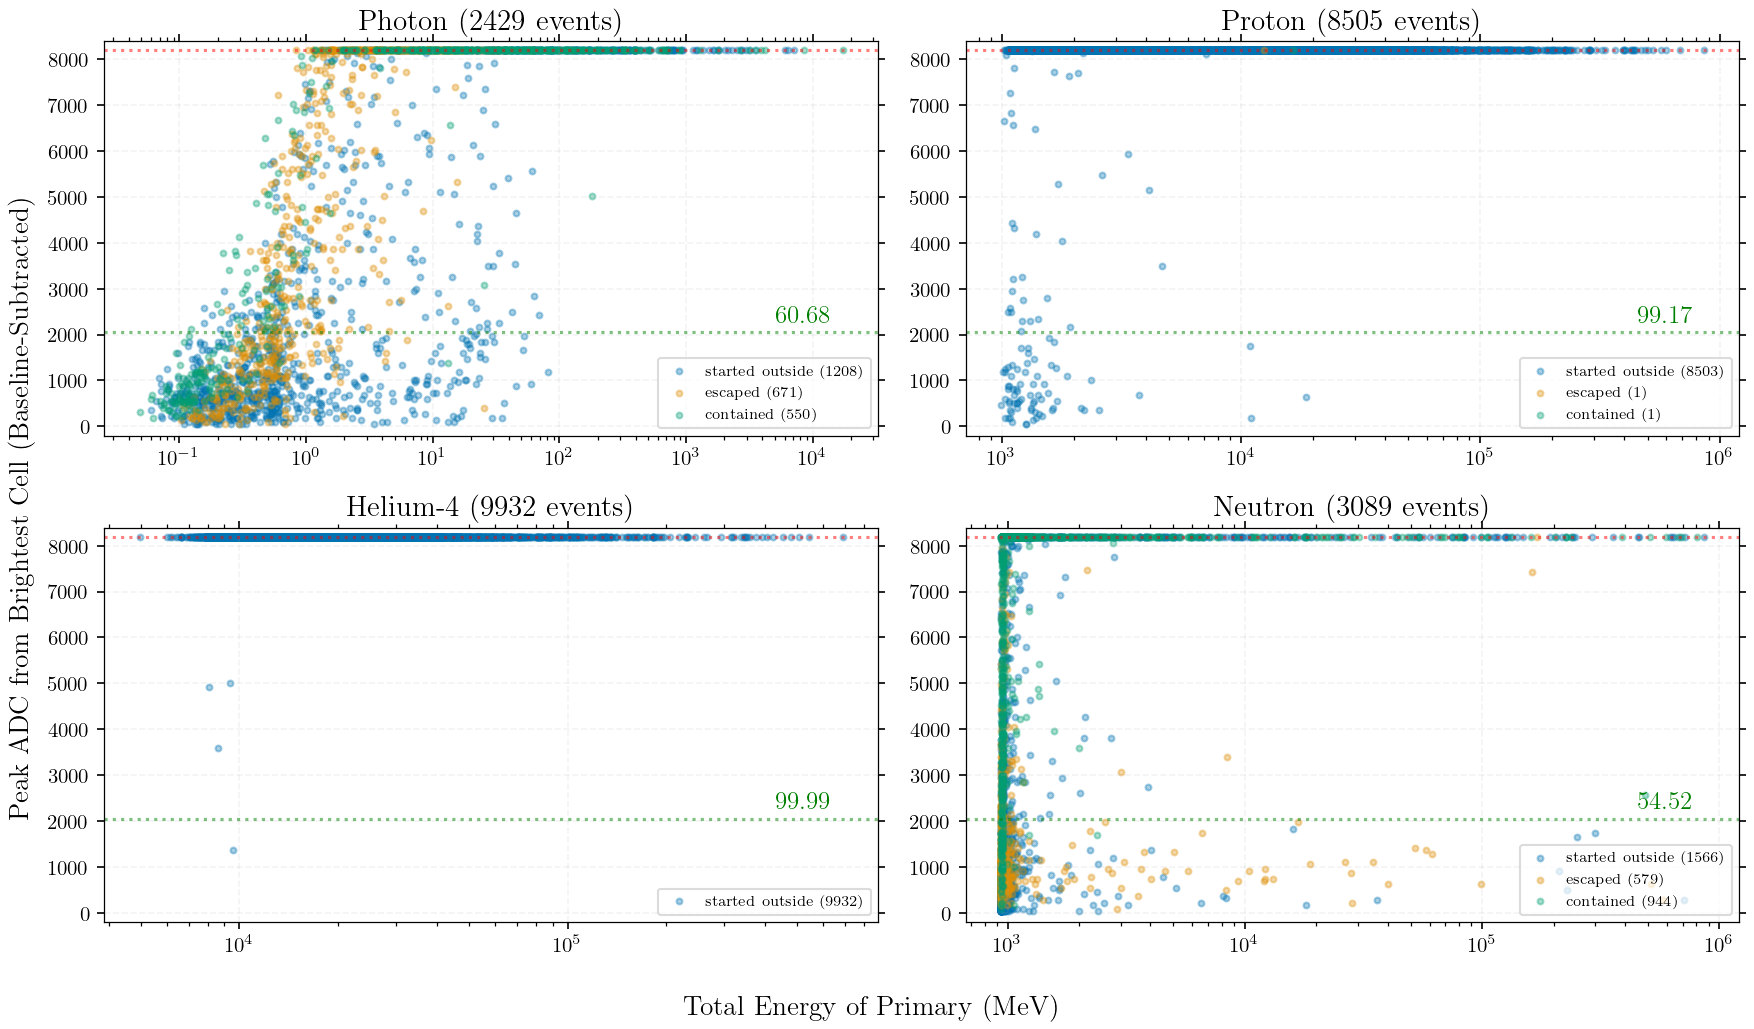

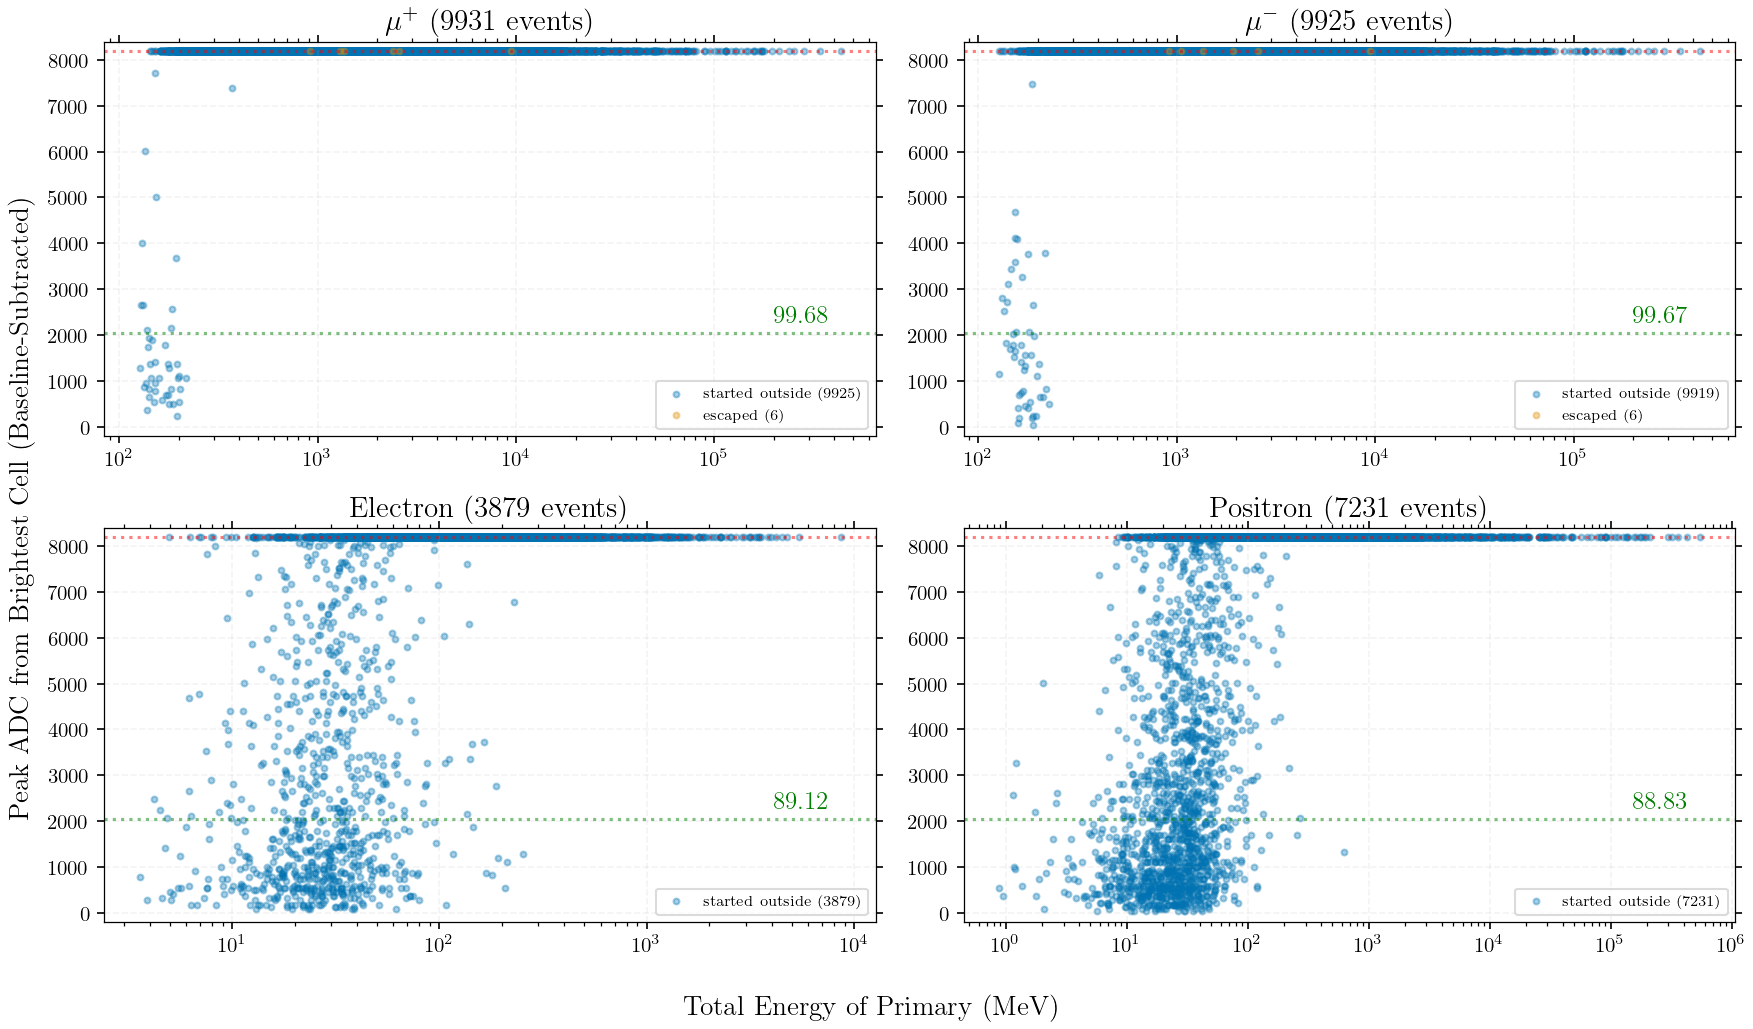

In [6]:
# Peak ADC vs primary energy scatter plots, colored by containment.
# Stored peak_adc is baseline-subtracted; add SUMMED_BASELINE_ADC back so the
# y-axis spans the full summed hardware range (0 to SUMMED_ADC_MAX = 16384).
from matplotlib.transforms import blended_transform_factory

group1 = ["photon", "proton", "he---4", "neutro"]
group2 = ["muplus", "mumins", "electr", "positr"]

containment_colors = {
    "contained":  colors[2],
    "escaped":    colors[1],
    "incomplete": colors[0],
    "inactive":   "0.6",
}
containment_order = ["inactive", "incomplete", "escaped", "contained"]

GREEN_THRESHOLD = 2048
RED_THRESHOLD = 2048 * 4


def peak_adc_grid(particle_list, df):
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    axes = axes.flatten()

    for ax, p in zip(axes, particle_list):
        sub = df[df["particle"] == p]
        if len(sub) == 0:
            ax.text(0.5, 0.5, "No Data", ha="center", transform=ax.transAxes)
            ax.set_title(particle_names.get(p, p))
            continue

        mask = (sub["peak_adc"] > 0) & (sub["primary_energy"] > 0)
        plotted = sub[mask]
        if len(plotted) == 0:
            ax.text(0.5, 0.5, "No nonzero data", ha="center", transform=ax.transAxes)
            ax.set_title(particle_names.get(p, p))
            continue

        for cname in containment_order:
            pts = plotted[plotted["containment"] == cname]
            if len(pts) == 0:
                continue
            if cname=="incomplete":
                label = "started outside"
            else:
                label = cname
            
            ax.scatter(
                pts["primary_energy"], pts["peak_adc"],
                alpha=0.35, s=8,
                color=containment_colors[cname],
                label=f"{label} ({len(pts)})",
            )

        ax.set_xscale("log")
        ax.set_ylim(-200, RED_THRESHOLD + 200)
        ax.axhline(RED_THRESHOLD, color="r", ls=":", lw=1.5, alpha=0.5)
        ax.axhline(GREEN_THRESHOLD, color="g", ls=":", lw=1.5, alpha=0.5)
        ax.set_title(f"{particle_names.get(p, p)} ({len(plotted)} events)")
        ax.grid(True, ls="--", alpha=0.15)
        ax.legend(fontsize=7, loc="lower right", framealpha=0.7)

        # fraction of plotted events above green dashed line,
        # placed just above the line on the right side
        n_above = int((plotted["peak_adc"] > GREEN_THRESHOLD).sum())
        frac = n_above / len(plotted)
        trans = blended_transform_factory(ax.transAxes, ax.transData)
        ax.text(
            0.94, GREEN_THRESHOLD + 120,
            f"{frac:.2%}$\%$",
            transform=trans, ha="right", va="bottom", fontsize=12, color="g",
        )

    fig.supxlabel("Total Energy of Primary (MeV)")
    fig.supylabel("Peak ADC from Brightest Cell (Baseline-Subtracted)")
    fig.tight_layout()
    plt.show()


peak_adc_grid(group1, events_df)
peak_adc_grid(group2, events_df)


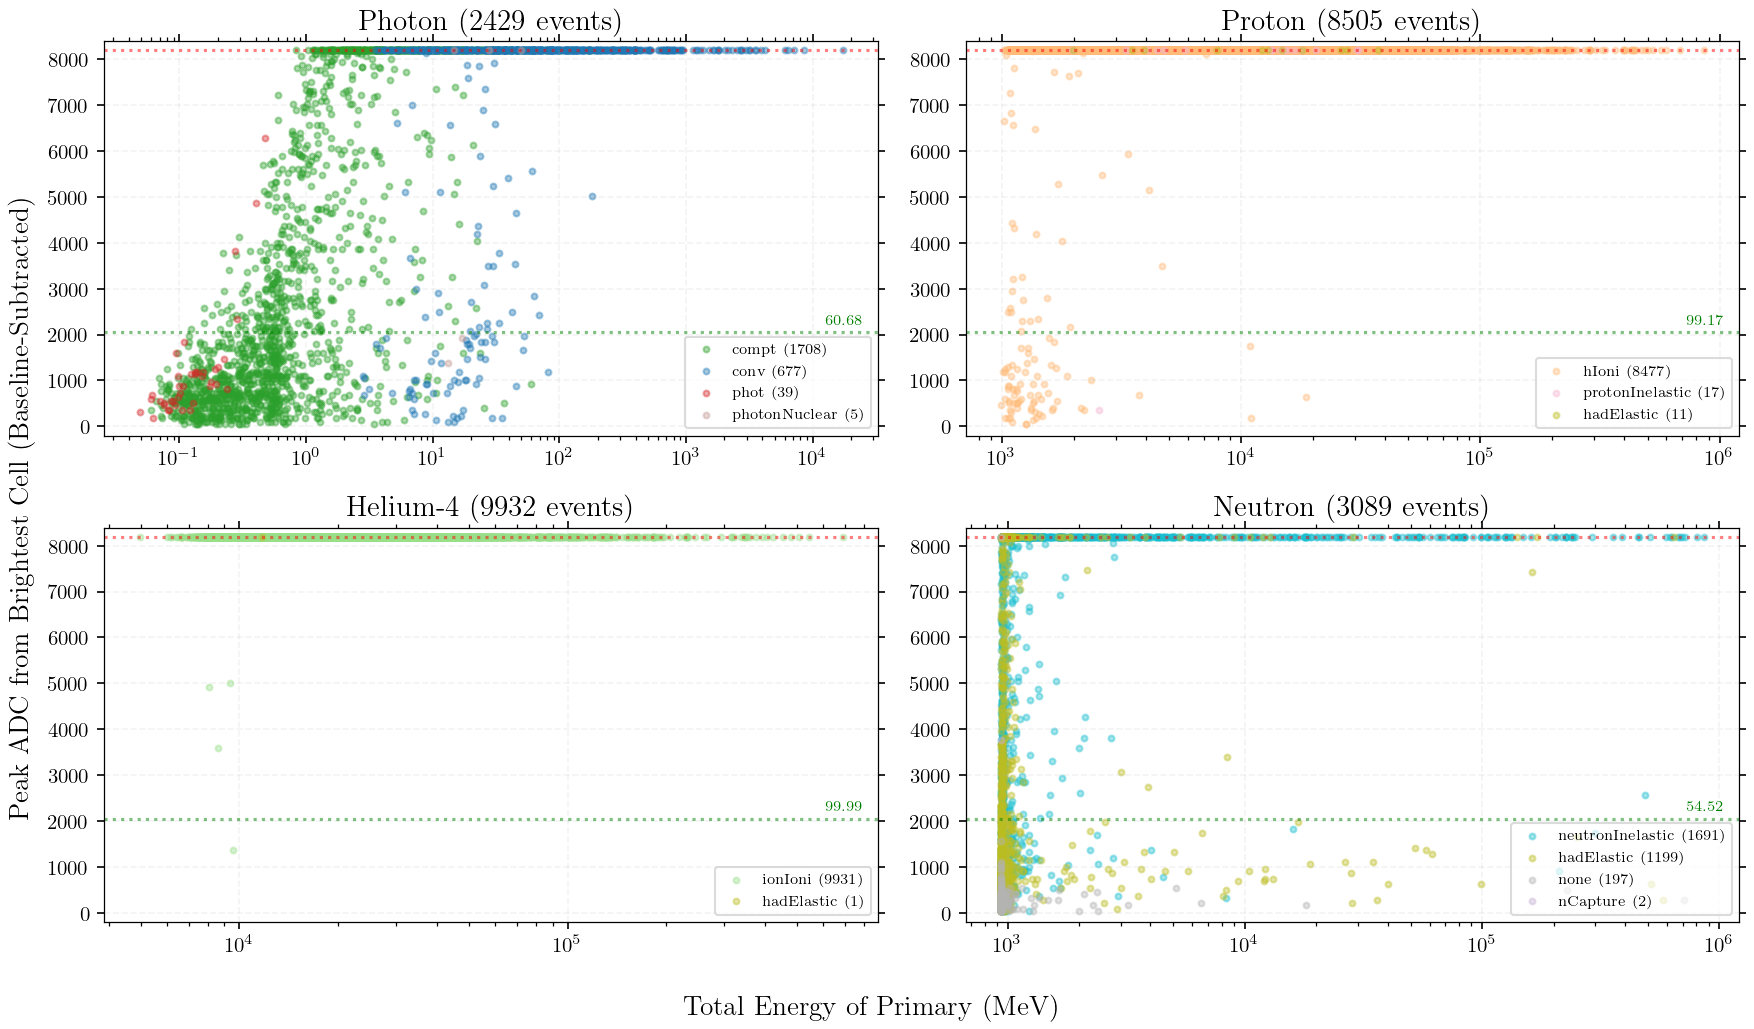

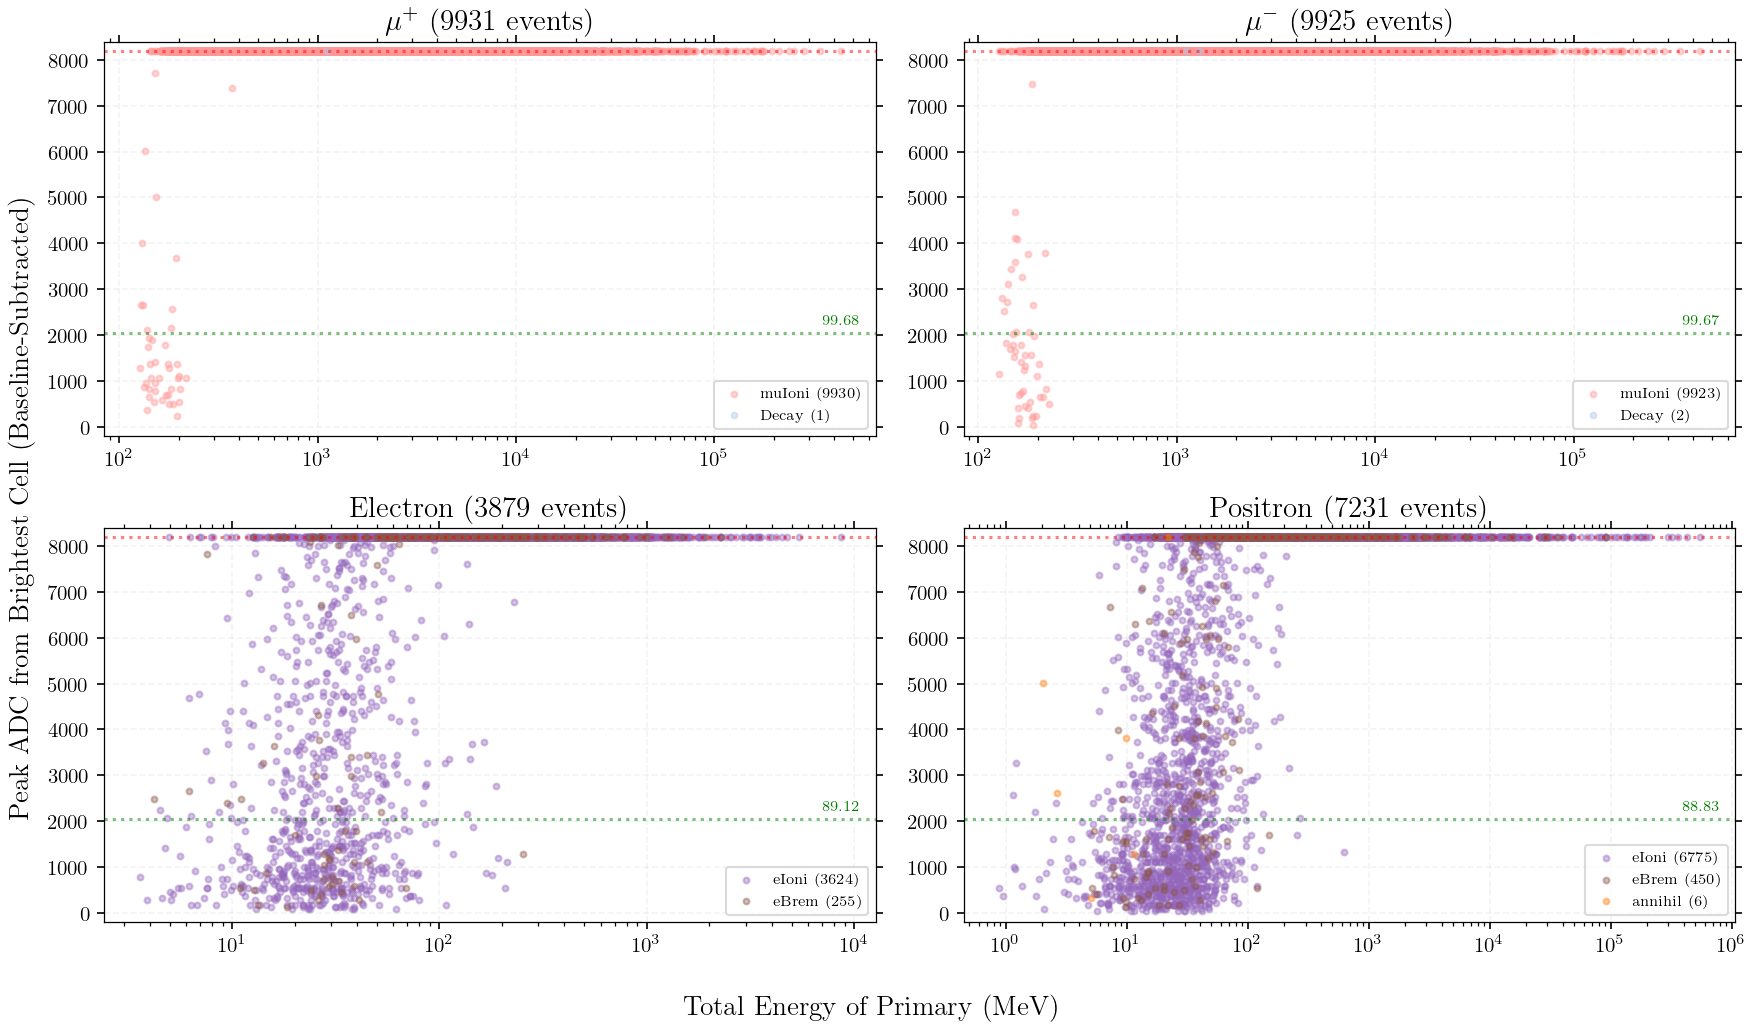

In [13]:
# Peak ADC vs primary energy scatter, colored by FIRST daughter process
# (first entry in the chronologically-ordered daughter_processes list).
# Stored peak_adc is baseline-subtracted; add SUMMED_BASELINE_ADC back.
events_df["first_daughter"] = (
    events_df["daughter_processes"]
    .fillna("")
    .str.split(",")
    .str[0]
    .replace("", "none")
)

# Explicit colors for well-known processes so visually similar ones
# (notably "conv" and "phot") are guaranteed distinct. Any label not in this
# table gets a fallback color that is checked against the fixed palette.
tab10 = sns.color_palette("tab10", 10)
fixed_process_colors = {
    "compt":            tab10[2],  # green
    "phot":             tab10[3],  # red
    "conv":             tab10[0],  # blue
    "eIoni":            tab10[4],  # purple
    "eBrem":            tab10[5],  # brown
    "msc":              tab10[6],  # pink
    "hadElastic":       tab10[8],  # olive
    "neutronInelastic": tab10[9],  # cyan
    "none":             "0.7",
}

process_labels = sorted(events_df["first_daughter"].unique())
fallback_palette = sns.color_palette("tab20", 20)
used = set(tuple(c) if not isinstance(c, str) else c for c in fixed_process_colors.values())
process_colors = {}
fallback_idx = 0
for lbl in process_labels:
    if lbl in fixed_process_colors:
        process_colors[lbl] = fixed_process_colors[lbl]
    else:
        while fallback_idx < len(fallback_palette) and tuple(fallback_palette[fallback_idx]) in used:
            fallback_idx += 1
        if fallback_idx < len(fallback_palette):
            process_colors[lbl] = fallback_palette[fallback_idx]
            fallback_idx += 1
        else:
            process_colors[lbl] = "k"


def peak_adc_grid_by_process(particle_list, df):
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    axes = axes.flatten()

    for ax, p in zip(axes, particle_list):
        sub = df[df["particle"] == p]
        mask = (sub["peak_adc"] > 0) & (sub["primary_energy"] > 0)
        plotted = sub[mask]
        if len(plotted) == 0:
            ax.text(0.5, 0.5, "No nonzero data", ha="center", transform=ax.transAxes)
            ax.set_title(particle_names.get(p, p))
            continue

        counts = plotted["first_daughter"].value_counts()
        for lbl in counts.index:
            pts = plotted[plotted["first_daughter"] == lbl]
            ax.scatter(
                pts["primary_energy"], pts["peak_adc"],
                alpha=0.4, s=8,
                color=process_colors.get(lbl, "k"),
                label=f"{lbl} ({len(pts)})",
            )

        ax.set_xscale("log")
        ax.set_ylim(-200, RED_THRESHOLD + 200)
        ax.axhline(RED_THRESHOLD, color="r", ls=":", lw=1.5, alpha=0.5)
        ax.axhline(GREEN_THRESHOLD, color="g", ls=":", lw=1.5, alpha=0.5)
        ax.set_title(f"{particle_names.get(p, p)} ({len(plotted)} events)")
        ax.grid(True, ls="--", alpha=0.15)
        ax.legend(fontsize=7, loc="lower right", framealpha=0.7)

        # fraction of plotted events above green dashed line,
        # placed just above the line on the right side
        n_above = int((plotted["peak_adc"] > GREEN_THRESHOLD).sum())
        frac = n_above / len(plotted)
        trans = blended_transform_factory(ax.transAxes, ax.transData)
        ax.text(
            0.98, GREEN_THRESHOLD + 120,
            f"{frac:.2%} $\%$ above",
            transform=trans, ha="right", va="bottom", fontsize=7, color="g",
        )

    fig.supxlabel("Total Energy of Primary (MeV)")
    fig.supylabel("Peak ADC from Brightest Cell (Baseline-Subtracted)")
    fig.tight_layout()
    plt.show()


peak_adc_grid_by_process(group1, events_df)
peak_adc_grid_by_process(group2, events_df)


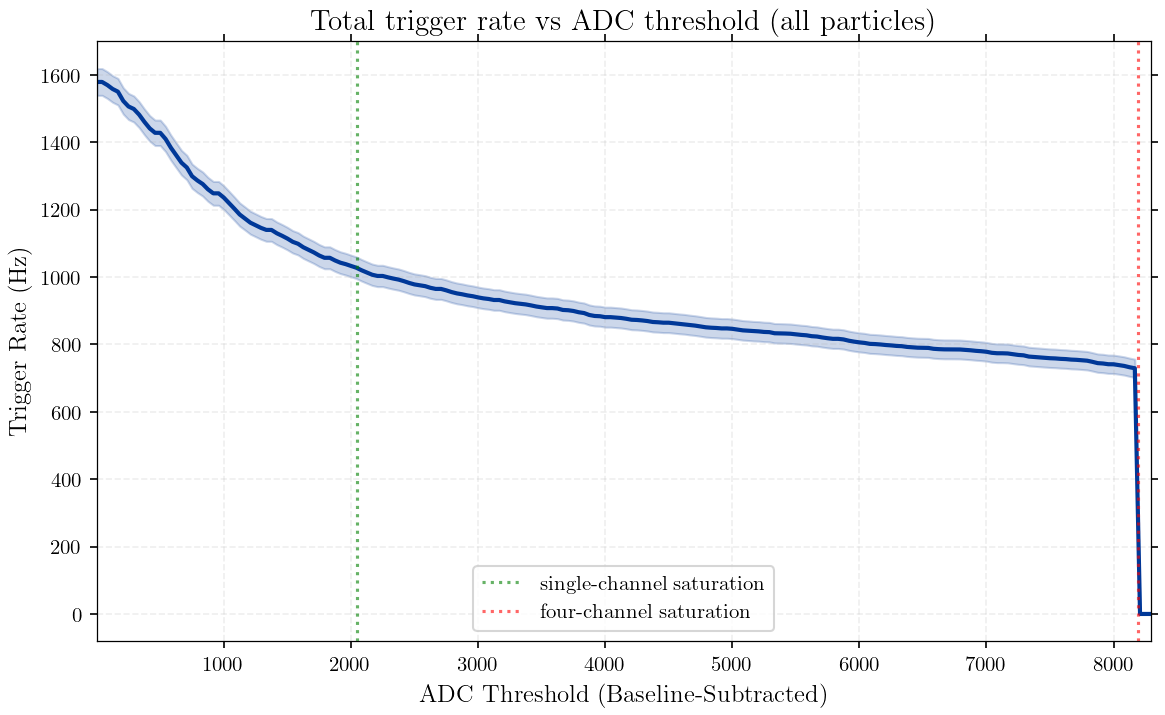

In [31]:
# Total trigger rate vs ADC threshold (all particles combined).
# Thresholds and x-axis are on the baseline-subtracted scale
# (0 to SUMMED_DYNAMIC_RANGE = 8192), matching the stored peak_adc.
peak_adc_by_particle = {
    p: events_df[events_df["particle"] == p]["peak_adc"].to_numpy()
    for p in PARTICLE_DICT.keys()
}

SUMMED_DYNAMIC_RANGE = SUMMED_ADC_MAX - SUMMED_BASELINE_ADC  # 8192
thresholds_adc = np.linspace(1, SUMMED_DYNAMIC_RANGE+100, 200).astype(int)

trigger_rates_all = []
for T in thresholds_adc:
    rate = 0.0
    for particle, peaks in peak_adc_by_particle.items():
        n_pass = int(np.count_nonzero(peaks >= T))
        rate += n_pass * weights[particle]["w"]
    trigger_rates_all.append(rate)
trigger_rates_all = np.array(trigger_rates_all)

plt.figure(figsize=(8, 5))
plt.plot(thresholds_adc, trigger_rates_all, "-", color="#003898", linewidth=2)
plt.fill_between(
    thresholds_adc,
    np.maximum(0, trigger_rates_all - np.sqrt(np.maximum(trigger_rates_all, 0))),
    trigger_rates_all + np.sqrt(np.maximum(trigger_rates_all, 0)),
    color="#003898", alpha=0.2,
)
plt.axvline(GREEN_THRESHOLD, color="g", ls=":", lw=1.5, alpha=0.6, label='single-channel saturation')
plt.axvline(RED_THRESHOLD, color="r", ls=":", lw=1.5, alpha=0.6, label='four-channel saturation')

# plt.semilogx()
plt.xlim(1, SUMMED_DYNAMIC_RANGE+100)
plt.xlabel("ADC Threshold (Baseline-Subtracted)")
plt.ylabel(r"Trigger Rate (Hz)")
plt.title("Total trigger rate vs ADC threshold (all particles)")
plt.grid(True, ls="--", alpha=0.2)
plt.legend(loc='lower center')
plt.tight_layout()
plt.show()


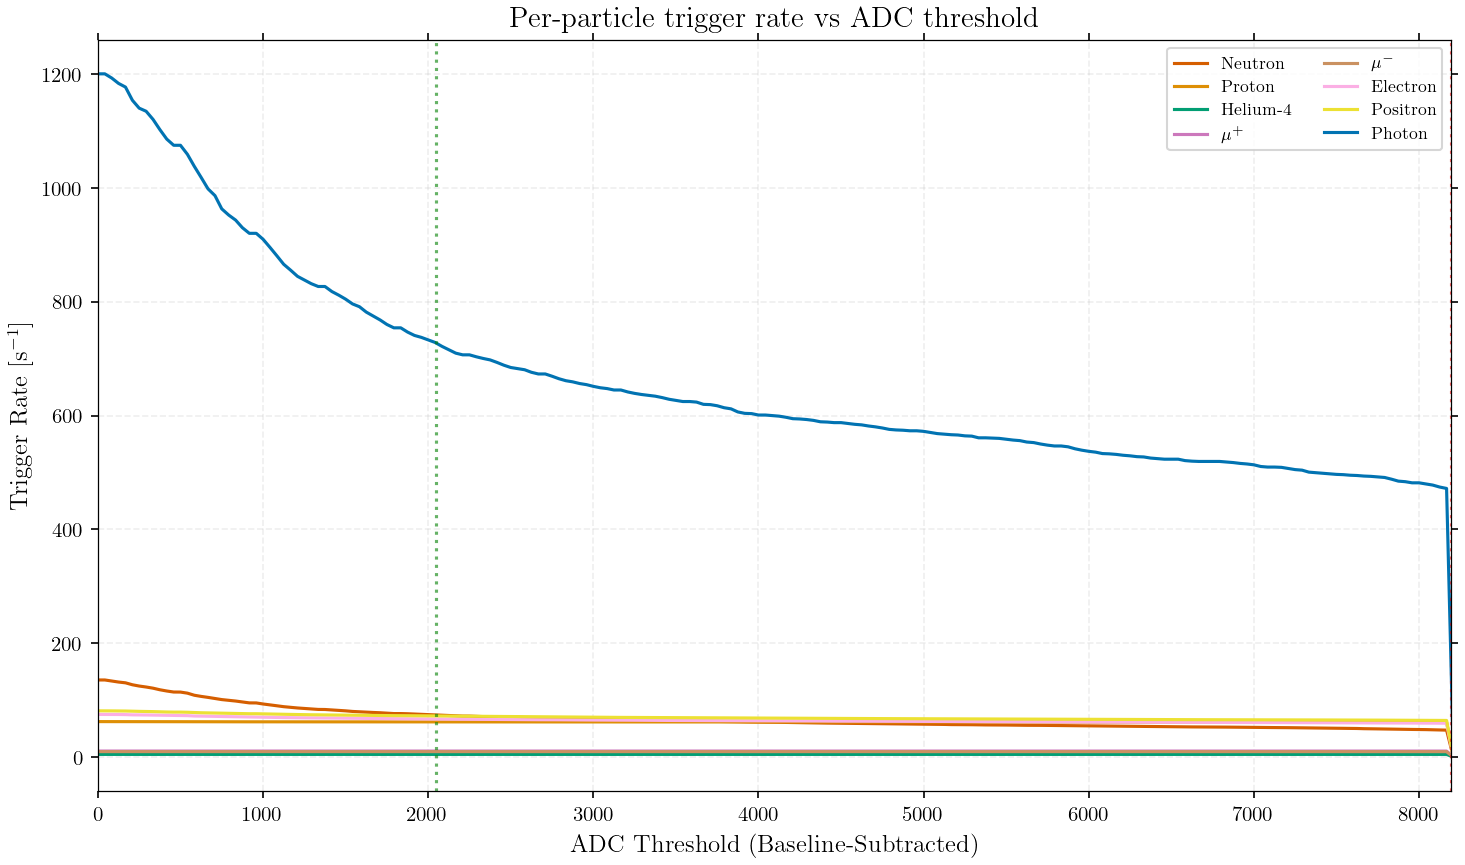

In [ ]:
# Per-particle trigger rate curves (baseline-subtracted linear x-axis)
plt.figure(figsize=(10, 6))

particle_colors = {
    "photon": colors[0], "proton": colors[1], "he---4": colors[2], "neutro": colors[3],
    "muplus": colors[4], "mumins": colors[5], "electr": colors[6], "positr": colors[8],
}

for particle in PARTICLE_DICT.keys():
    peaks = peak_adc_by_particle[particle]
    w = weights[particle]["w"]
    rates = np.array([np.count_nonzero(peaks >= T) * w for T in thresholds_adc])

    plt.plot(thresholds_adc, rates, "-",
             color=particle_colors.get(particle, "k"),
             label=particle_names.get(particle, particle))

plt.axvline(GREEN_THRESHOLD, color="g", ls=":", lw=1.5, alpha=0.6)
plt.axvline(RED_THRESHOLD, color="r", ls=":", lw=1.5, alpha=0.6)
plt.xlim(0, SUMMED_DYNAMIC_RANGE)
plt.xlabel("ADC Threshold (Baseline-Subtracted)")
plt.ylabel(r"Trigger Rate (Hz)]")
plt.title("Per-particle trigger rate vs ADC threshold")
plt.legend(fontsize=8, ncol=2)
plt.grid(True, ls="--", alpha=0.2)
plt.tight_layout()
plt.show()


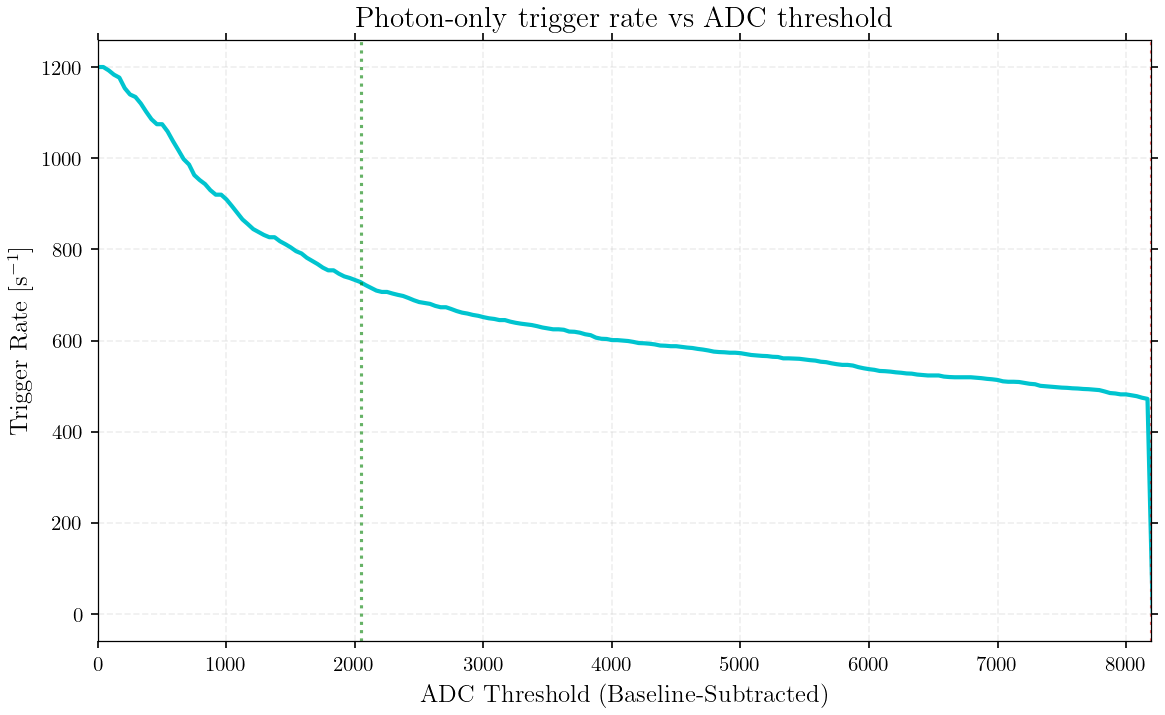

In [ ]:
# Photon-only trigger rate vs ADC threshold (baseline-subtracted linear x-axis)
peaks_photon = peak_adc_by_particle["photon"]
w_photon = weights["photon"]["w"]
trigger_rates_photon = np.array(
    [np.count_nonzero(peaks_photon >= T) * w_photon for T in thresholds_adc]
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds_adc, trigger_rates_photon, "-", color="#00C4CF", linewidth=2)
plt.axvline(GREEN_THRESHOLD, color="g", ls=":", lw=1.5, alpha=0.6)
plt.axvline(RED_THRESHOLD, color="r", ls=":", lw=1.5, alpha=0.6)
plt.xlim(0, SUMMED_DYNAMIC_RANGE)
plt.xlabel("ADC Threshold (Baseline-Subtracted)")
plt.ylabel(r"Trigger Rate (Hz)")
plt.title("Photon-only trigger rate vs ADC threshold")
plt.grid(True, ls="--", alpha=0.2)
plt.tight_layout()
plt.show()


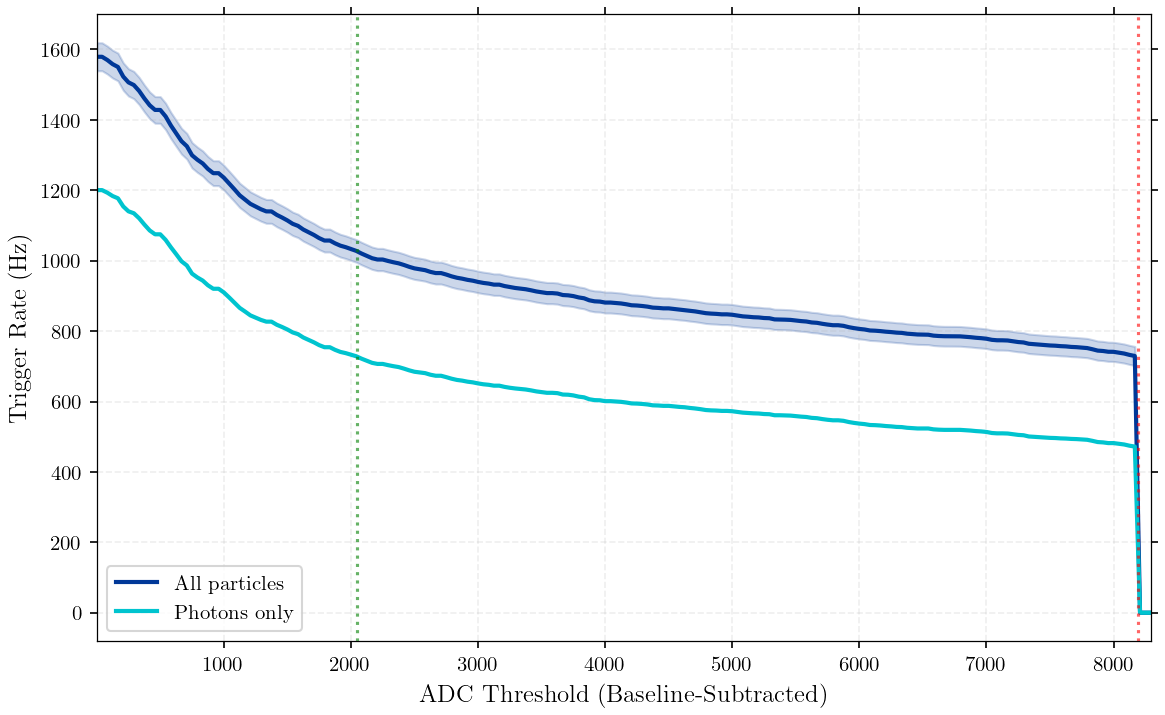

In [33]:
# Comparison: all particles vs photons only
plt.figure(figsize=(8, 5))
plt.plot(thresholds_adc, trigger_rates_all, "-", color="#003898", linewidth=2, label="All particles")
plt.fill_between(
    thresholds_adc,
    np.maximum(0, trigger_rates_all - np.sqrt(np.maximum(trigger_rates_all, 0))),
    trigger_rates_all + np.sqrt(np.maximum(trigger_rates_all, 0)),
    color="#003898", alpha=0.2,
)
plt.plot(thresholds_adc, trigger_rates_photon, "-", color="#00C4CF", linewidth=2, label="Photons only")
plt.axvline(GREEN_THRESHOLD, color="g", ls=":", lw=1.5, alpha=0.6)
plt.axvline(RED_THRESHOLD, color="r", ls=":", lw=1.5, alpha=0.6)
plt.xlim(1, SUMMED_DYNAMIC_RANGE+100)
plt.xlabel("ADC Threshold (Baseline-Subtracted)")
plt.ylabel(r"Trigger Rate (Hz)")
plt.legend()
plt.grid(True, ls="--", alpha=0.2)
plt.tight_layout()
plt.show()
